In [3]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap,
                receptor_distances,
                full_array_entropy,
                mean_receptor_distance)
from run import initialize,train,test
# 2. Apply the REVTeX look using internal fonts
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],      # Times-like font bundled with MPL
    "mathtext.fontset": "cm",           # Computer Modern math look
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 0.8,
    "font.size": 11
})

In [ ]:
n_units=5
k_sub = 5
n_families = 10
N_train = 2**17
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 10,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.5,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 0.1,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":True,
        "temperature":0.1,
    }

In [7]:
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)

Fitting UMAP... (This may take a few seconds)


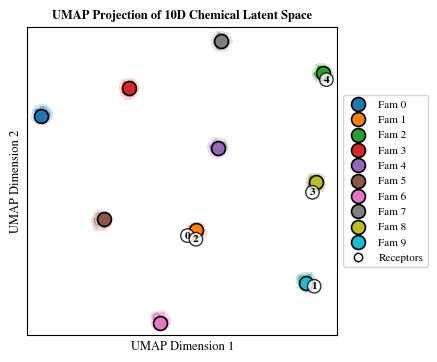

In [8]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])

In [9]:
train_out = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance,])

Training for 5000 epochs...


Fitting UMAP... (This may take a few seconds)


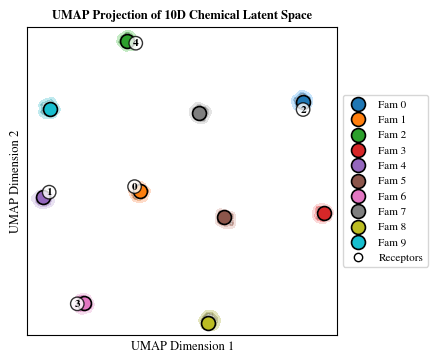

In [10]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])

In [12]:
CONF.update({"mc_freq": 0,"use_scheduler":False})
env, rec, loss_fn, optimize = initialize(CONF, SymmetricEnv=False)
train_out_no_mc = train(CONF, env, rec, loss_fn, optimize,measurement_fns=[full_array_entropy,mean_receptor_distance])

Training for 5000 epochs...


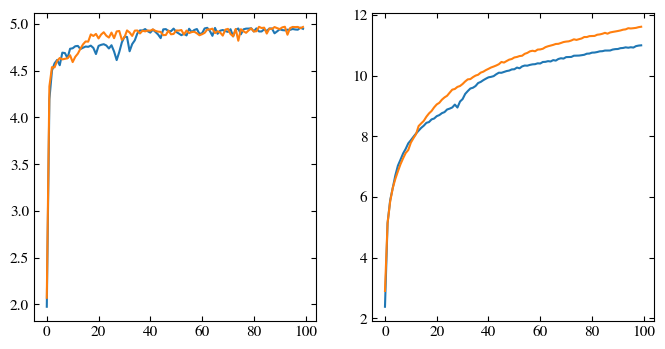

In [13]:
fig,ax = plt.subplots(ncols=2,figsize=(8,4))
ax[0].plot(train_out['full_array_entropy'])
ax[0].plot(train_out_no_mc['full_array_entropy'])

ax[1].plot(train_out['mean_receptor_distance'])
ax[1].plot(train_out_no_mc['mean_receptor_distance'])

Fitting UMAP... (This may take a few seconds)


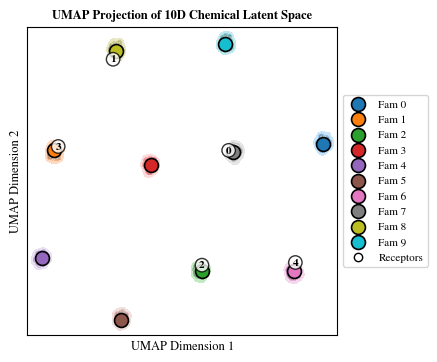

In [24]:
fig,ax = plot_latent_umap(env,CONF['receptor_indices'])

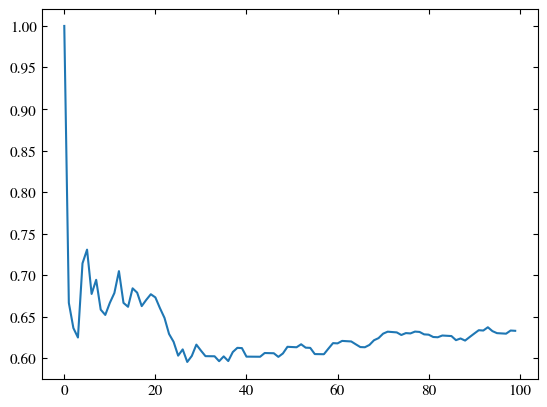

In [25]:
plt.plot(train_out['mc_acceptance_rate'])